In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))


df = pd.read_csv(file_name)

# SETTINGS
T = 800
dt = 0.01
eta_go = 0.7
eta_ir = 0.9
eta_cv = 0.5

# WEIGHTS
sigma1 = 0.5
sigma2 = 0.5

alpha2 = 0.75

alpha3 = 0.6
beta3 = 0.5

delta4 = 0.6667
alpha4 = 0.3333
beta4 = 0.6667
lambda4 = 0.5

alpha5 = 0.3
beta5 = 0.8571
lambda5 = 1.0

alpha6 = 0.8571

alpha7 = 0.6
beta7 = 0.5

alpha8 = 0.5
alpha9 = 0.5

delta10 = 0.6
alpha10 = 0.6
beta10 = 0.5

alpha11 = 0.5
alpha12 = 0.6
beta12 = 0.8

# SAFE CLIP FUNCTION
def clip(v):
    return np.clip(v, 0.05, 0.95)

# CLASSIFICATION
def classify_support(v):
    if v >= 0.75:
        return "High Support"
    elif v >= 0.55:
        return "Moderate Support"
    elif v >= 0.35:
        return "Low Support"
    else:
        return "Very Low Support"


def classify_disturbance(v):
    if v <= 0.25:
        return "Low Disturbance"
    elif v <= 0.45:
        return "Mild Disturbance"
    elif v <= 0.65:
        return "High Disturbance"
    else:
        return "Severe Disturbance"


def classify_crop_viability(v):
    if v >= 0.75:
        return "Healthy"
    elif v >= 0.55:
        return "Moderate"
    elif v >= 0.35:
        return "Warning"
    else:
        return "Critical"

# MODEL
def run_crop_model(row, T=800, dt=0.01, eta_go=0.7, eta_ir=0.9, eta_cv=0.5):

    i1 = np.ones(T) * row["i1_nutrient_level_balance"]
    i2 = np.ones(T) * row["i2_soil_context"]
    i3 = np.ones(T) * row["i3_atmospheric_support"]
    i4 = np.ones(T) * row["i4_atmospheric_stress"]
    i5 = np.ones(T) * row["i5_water_support"]
    i6 = np.ones(T) * row["i6_water_deficit"]
    i7 = np.ones(T) * row["i7_growth_readiness"]
    i8 = np.ones(T) * row["i8_biotic_env_stress"]
    i9 = np.ones(T) * row["i9_management_context"]

    # CONDITION LAYER
    Sc = np.zeros(T)   # Soil Condition
    Ac = np.zeros(T)   # Atmospheric Condition
    Wc = np.zeros(T)   # Water Condition
    Gc = np.zeros(T)   # Growth Condition
    Cs = np.zeros(T)   # Contextual Sensitivity

    # BEHAVIOR LAYER
    Es = np.zeros(T)   # Environmental Suitability
    Gp = np.zeros(T)   # Growth Potential
    Sp = np.zeros(T)   # Stress Pressure
    Rp = np.zeros(T)   # Risk Propagation
    Sb = np.zeros(T)   # Stability

    Go = np.zeros(T)   # Growth Outlook
    Ir = np.zeros(T)   # Immediate Risk
    Cv = np.zeros(T)   # Crop Viability

    # LONG-TERM OUTPUT LAYER
    LGo = np.zeros(T)  # Long-Term Growth Outlook
    LIr = np.zeros(T)  # Long-Term Immediate Risk
    LCv = np.zeros(T)  # Long-Term Crop Viability

    #  INITIAL =
    Sc[0] = clip(sigma1 * i1[0] + sigma2 * i2[0])

    Ac[0] = clip((1 - i4[0]) * (alpha2 * i3[0] + (1 - alpha2) * i7[0]))

    Wc[0] = clip(
        (1 - i5[0]) * (
            alpha3 * i6[0] +
            (1 - alpha3) * (beta3 * (i4[0] + i7[0]))
        )
    )

    Gc[0] = clip(
        (1 - (delta4 * i4[0] + (1 - delta4) * i6[0])) * (
            alpha4 * i7[0] +
            (1 - alpha4) * (
                beta4 * (i5[0] + i3[0]) +
                (1 - beta4) * (lambda4 * (i1[0] + i2[0]))
            )
        )
    )

    Cs[0] = clip(
        alpha5 * i8[0] +
        (1 - alpha5) * (
            beta5 * (i4[0] + i6[0] + i9[0]) +
            (1 - beta5) * (lambda5 * i7[0])
        )
    )

    Es[0] = clip(alpha6 * (Sc[0] + Ac[0]) + (1 - alpha6) * Gc[0])

    Gp[0] = clip(
        (1 - Wc[0]) * (
            alpha7 * Gc[0] +
            (1 - alpha7) * (beta7 * (Sc[0] + Ac[0]))
        )
    )

    Sp[0] = clip((1 - Ac[0]) * (alpha8 * (Wc[0] + Cs[0])))

    Rp[0] = clip((1 - Gc[0]) * (alpha9 * (Wc[0] + Cs[0])))

    Sb[0] = clip(
        (1 - (delta10 * Wc[0] + (1 - delta10) * Cs[0])) * (
            alpha10 * Sc[0] +
            (1 - alpha10) * (beta10 * (Ac[0] + Gc[0]))
        )
    )

    Go[0] = clip(
        (1 - Sp[0]) * (
            alpha12 * (Es[0] + Gp[0]) +
            (1 - alpha12) * (beta12 * Sb[0])
        )
    )

    Ir[0] = clip((1 - Sb[0]) * (alpha11 * (Sp[0] + Rp[0])))

    Cv[0] = clip(Go[0] * (1 - Ir[0]))

    #  LONG-TERM INITIAL
    LGo[0] = 0.1
    LIr[0] = 0.9
    LCv[0] = 0.1

    for t in range(1, T):

        Sc[t] = clip(sigma1 * i1[t] + sigma2 * i2[t])

        Ac[t] = clip((1 - i4[t]) * (alpha2 * i3[t] + (1 - alpha2) * i7[t]))

        Wc[t] = clip(
            (1 - i5[t]) * (
                alpha3 * i6[t] +
                (1 - alpha3) * (beta3 * (i4[t] + i7[t]))
            )
        )

        Gc[t] = clip(
            (1 - (delta4 * i4[t] + (1 - delta4) * i6[t])) * (
                alpha4 * i7[t] +
                (1 - alpha4) * (
                    beta4 * (i5[t] + i3[t]) +
                    (1 - beta4) * (lambda4 * (i1[t] + i2[t]))
                )
            )
        )

        Cs[t] = clip(
            alpha5 * i8[t] +
            (1 - alpha5) * (
                beta5 * (i4[t] + i6[t] + i9[t]) +
                (1 - beta5) * (lambda5 * i7[t])
            )
        )

        Es[t] = clip(alpha6 * (Sc[t] + Ac[t]) + (1 - alpha6) * Gc[t])

        Gp[t] = clip(
            (1 - Wc[t]) * (
                alpha7 * Gc[t] +
                (1 - alpha7) * (beta7 * (Sc[t] + Ac[t]))
            )
        )

        Sp[t] = clip((1 - Ac[t]) * (alpha8 * (Wc[t] + Cs[t])))

        Rp[t] = clip((1 - Gc[t]) * (alpha9 * (Wc[t] + Cs[t])))

        Sb[t] = clip(
            (1 - (delta10 * Wc[t] + (1 - delta10) * Cs[t])) * (
                alpha10 * Sc[t] +
                (1 - alpha10) * (beta10 * (Ac[t] + Gc[t]))
            )
        )

        Go[t] = clip(
            (1 - Sp[t]) * (
                alpha12 * (Es[t] + Gp[t]) +
                (1 - alpha12) * (beta12 * Sb[t])
            )
        )

        Ir[t] = clip((1 - Sb[t]) * (alpha11 * (Sp[t] + Rp[t])))

        Cv[t] = clip(Go[t] * (1 - Ir[t]))

        LGo[t] = clip(LGo[t - 1] + eta_go * (Go[t - 1] - LGo[t - 1]) * dt)
        LIr[t] = clip(LIr[t - 1] + eta_ir * (Ir[t - 1] - LIr[t - 1]) * dt)
        LCv[t] = clip(LCv[t - 1] + eta_cv * (Cv[t - 1] - LCv[t - 1]) * dt)

    return {
    "Sc (Soil_Condition)": Sc,
    "Ac (Atmospheric_Condition)": Ac,
    "Wc (Water_Condition)": Wc,
    "Gc (Growth_Condition)": Gc,
    "Cs (Contextual_Sensitivity)": Cs,

    "Es (Environmental_Suitability)": Es,
    "Gp (Growth_Potential)": Gp,
    "Sp (Stress_Pressure)": Sp,
    "Rp (Risk_Propagation)": Rp,
    "Sb (Stability)": Sb,

    "Go (Growth_Outlook)": Go,
    "Ir (Immediate_Risk)": Ir,
    "Cv (Crop_Viability)": Cv,

    "LGo (LongTerm_Growth_Outlook)": LGo,
    "LIr (LongTerm_Immediate_Risk)": LIr,
    "LCv (LongTerm_Crop_Viability)": LCv
}

Saving crop_ict358.csv to crop_ict358.csv


In [ ]:
# RUN MODEL + STORE RESULTS

results = []

for _, row in df.iterrows():
    sim = run_crop_model(
        row,
        T=T,
        dt=dt,
        eta_go=eta_go,
        eta_ir=eta_ir,
        eta_cv=eta_cv
    )

    results.append({
        "crop_type": row["label"],

        # CONDITION LAYER
        "Sc (Soil_Condition)": round(sim["Sc (Soil_Condition)"][-1], 4),
        "Ac (Atmospheric_Condition)": round(sim["Ac (Atmospheric_Condition)"][-1], 4),
        "Wc (Water_Condition)": round(sim["Wc (Water_Condition)"][-1], 4),
        "Gc (Growth_Condition)": round(sim["Gc (Growth_Condition)"][-1], 4),
        "Cs (Contextual_Sensitivity)": round(sim["Cs (Contextual_Sensitivity)"][-1], 4),

        # BEHAVIOR LAYER
        "Es (Environmental_Suitability)": round(sim["Es (Environmental_Suitability)"][-1], 4),
        "Gp (Growth_Potential)": round(sim["Gp (Growth_Potential)"][-1], 4),
        "Sp (Stress_Pressure)": round(sim["Sp (Stress_Pressure)"][-1], 4),
        "Rp (Risk_Propagation)": round(sim["Rp (Risk_Propagation)"][-1], 4),
        "Sb (Stability)": round(sim["Sb (Stability)"][-1], 4),

        # SHORT-TERM OUTPUT
        "Go (Growth_Outlook)": round(sim["Go (Growth_Outlook)"][-1], 4),
        "Ir (Immediate_Risk)": round(sim["Ir (Immediate_Risk)"][-1], 4),
        "Cv (Crop_Viability)": round(sim["Cv (Crop_Viability)"][-1], 4),

        # LONG-TERM OUTPUT
        "LGo (LongTerm_Growth_Outlook)": round(sim["LGo (LongTerm_Growth_Outlook)"][-1], 4),
        "LIr (LongTerm_Immediate_Risk)": round(sim["LIr (LongTerm_Immediate_Risk)"][-1], 4),
        "LCv (LongTerm_Crop_Viability)": round(sim["LCv (LongTerm_Crop_Viability)"][-1], 4),

        # CLASSIFICATION
        "support_state": classify_support(sim["LGo (LongTerm_Growth_Outlook)"][-1]),
        "disturbance_state": classify_disturbance(sim["LIr (LongTerm_Immediate_Risk)"][-1]),
        "crop_state": classify_crop_viability(sim["LCv (LongTerm_Crop_Viability)"][-1])
    })

# CREATE DATAFRAME
results_df = pd.DataFrame(results)

# CHECK
print(results_df.shape)
print(results_df.head())



(2200, 20)
  crop_type  Sc (Soil_Condition)  Ac (Atmospheric_Condition)  \
0      rice               0.5633                      0.6142   
1      rice               0.5814                      0.4963   
2      rice               0.5736                      0.5200   
3      rice               0.6054                      0.5150   
4      rice               0.5906                      0.5920   

   Wc (Water_Condition)  Gc (Growth_Condition)  Cs (Contextual_Sensitivity)  \
0                0.0659                 0.7741                       0.8044   
1                0.1412                 0.5687                       0.8396   
2                0.0669                 0.7178                       0.7940   
3                0.0914                 0.7179                       0.6230   
4                0.0741                 0.7639                       0.9500   

   Es (Environmental_Suitability)  Gp (Growth_Potential)  \
0                            0.95                 0.6538   
1        

In [ ]:
# SAVE FILE
# =========================
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = f"crop_health_results_{timestamp}.csv"

results_df.to_csv(output_file, index=False)

print(f"\nSaved as: {output_file}")

# DOWNLOAD (Colab)
from google.colab import files
files.download(output_file)


Saved as: crop_health_results_20260525_123924.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("results exists:", 'results' in globals())
print("results_df exists:", 'results_df' in globals())

results exists: True
results_df exists: True


In [ ]:
print("\nCrop State Counts:")
print(results_df["crop_state"].value_counts())


Crop State Counts:
crop_state
Moderate    1064
Warning      835
Healthy      196
Critical     105
Name: count, dtype: int64



Row ID: 3
Crop Type: rice
Final Crop State: Healthy

Target values:
GO target: 0.8787
IR target: 0.0789
CV target: 0.8094

Final long-term values:
LGO: 0.8758
LIR: 0.0795
LCV: 0.7965


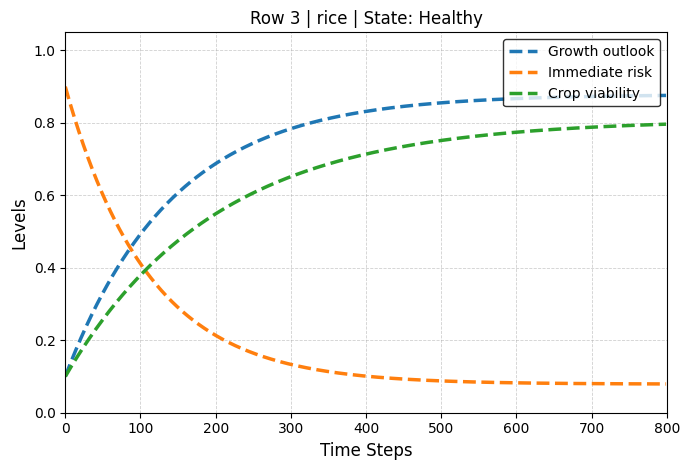

In [ ]:
# PLOT ONE SPECIFIC ROW

plot_row_idx = 3
row = df.iloc[plot_row_idx]

sim = run_crop_model(
    row,
    T=T,
    dt=dt,
    eta_go=eta_go,
    eta_ir=eta_ir,
    eta_cv=eta_cv
)

# EXTRACT VALUES
LGo = sim["LGo (LongTerm_Growth_Outlook)"]
LIr = sim["LIr (LongTerm_Immediate_Risk)"]
LCv = sim["LCv (LongTerm_Crop_Viability)"]

# LABELS
crop_label = row["label"]
crop_state = classify_crop_viability(LCv[-1])
row_id = plot_row_idx

# PRINT
print(f"\nRow ID: {row_id}")
print(f"Crop Type: {crop_label}")
print(f"Final Crop State: {crop_state}")

print("\nTarget values:")
print("GO target:", round(sim["Go (Growth_Outlook)"][-1], 4))
print("IR target:", round(sim["Ir (Immediate_Risk)"][-1], 4))
print("CV target:", round(sim["Cv (Crop_Viability)"][-1], 4))

print("\nFinal long-term values:")
print("LGO:", round(LGo[-1], 4))
print("LIR:", round(LIr[-1], 4))
print("LCV:", round(LCv[-1], 4))

#PLOT
time = np.arange(T)

plt.figure(figsize=(7, 4.8))

plt.plot(time, LGo, linestyle="--", linewidth=2.5, label="Growth outlook")
plt.plot(time, LIr, linestyle="--", linewidth=2.5, label="Immediate risk")
plt.plot(time, LCv, linestyle="--", linewidth=2.5, label="Crop viability")

plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Levels", fontsize=12)

plt.xlim(0, T)
plt.ylim(0, 1.05)

# TITLE
plt.title(
    f"Row {row_id} | {crop_label} | State: {crop_state}",
    fontsize=12
)

plt.legend(loc="upper right", fontsize=10, frameon=True, edgecolor="black")

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

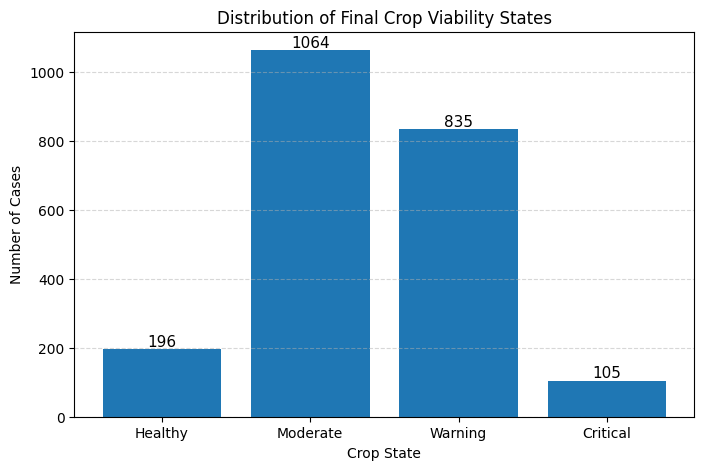

In [ ]:
# CROP STATE DISTRIBUTION

crop_state_counts = results_df["crop_state"].value_counts()

state_order = ["Healthy", "Moderate", "Warning", "Critical"]
crop_state_counts = crop_state_counts.reindex(state_order, fill_value=0)

plt.figure(figsize=(8, 5))
bars = plt.bar(crop_state_counts.index, crop_state_counts.values)

plt.xlabel("Crop State")
plt.ylabel("Number of Cases")
plt.title("Distribution of Final Crop Viability States")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# show values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.show()

In [ ]:
# AVERAGE HEALTH INDEX FOR ALL CROPS

avg_health = results_df["LCv (LongTerm_Crop_Viability)"].mean()
overall_state = classify_crop_viability(avg_health)

state_counts = results_df["crop_state"].value_counts()
state_percentages = results_df["crop_state"].value_counts(normalize=True) * 100

print("Average Crop Health Index:", round(avg_health, 4))
print("Overall System State:", overall_state)

print("\nCrop State Counts:")
print(state_counts)

print("\nCrop State Percentages:")
print(state_percentages.round(2))

summary_df = pd.DataFrame({
    "count": state_counts,
    "percentage": state_percentages.round(2)
})

print("\nSummary Table:")
print(summary_df)


# NEW: AVERAGE HEALTH PER CROP TYPE

crop_health_summary = results_df.groupby("crop_type").agg({
    "LCv (LongTerm_Crop_Viability)": "mean"
}).reset_index()

crop_health_summary.rename(columns={
    "LCv (LongTerm_Crop_Viability)": "avg_health"
}, inplace=True)

# classify each crop type
crop_health_summary["overall_state"] = crop_health_summary["avg_health"].apply(classify_crop_viability)

# sort best → worst
crop_health_summary = crop_health_summary.sort_values(by="avg_health", ascending=False)

print("\nAverage Health per Crop Type:")
print(crop_health_summary)

Average Crop Health Index: 0.574
Overall System State: Moderate

Crop State Counts:
crop_state
Moderate    1064
Warning      835
Healthy      196
Critical     105
Name: count, dtype: int64

Crop State Percentages:
crop_state
Moderate    48.36
Warning     37.95
Healthy      8.91
Critical     4.77
Name: proportion, dtype: float64

Summary Table:
            count  percentage
crop_state                   
Moderate     1064       48.36
Warning       835       37.95
Healthy       196        8.91
Critical      105        4.77

Average Health per Crop Type:
      crop_type  avg_health overall_state
0         apple    0.702036      Moderate
19  pomegranate    0.661639      Moderate
20         rice    0.659450      Moderate
6        cotton    0.637201      Moderate
16       orange    0.629100      Moderate
4       coconut    0.624627      Moderate
1        banana    0.616989      Moderate
21   watermelon    0.616202      Moderate
7        grapes    0.615522      Moderate
8          jute    0.61

In [ ]:
# BEST AND WORST CROP TYPES

best_crop = crop_health_summary.iloc[0]
worst_crop = crop_health_summary.iloc[-1]

print("\nBest Performing Crop:")
print(f"{best_crop['crop_type']} | Health: {round(best_crop['avg_health'], 4)} | State: {best_crop['overall_state']}")

print("\nWorst Performing Crop:")
print(f"{worst_crop['crop_type']} | Health: {round(worst_crop['avg_health'], 4)} | State: {worst_crop['overall_state']}")


Best Performing Crop:
apple | Health: 0.702 | State: Moderate

Worst Performing Crop:
mango | Health: 0.374 | State: Warning


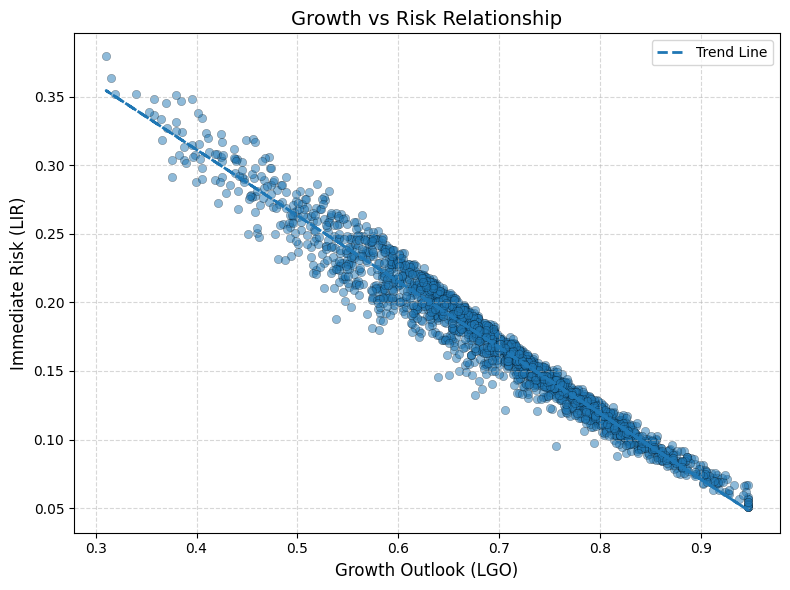

In [ ]:
plt.figure(figsize=(8, 6))

# scatter
plt.scatter(
    results_df["LGo (LongTerm_Growth_Outlook)"],
    results_df["LIr (LongTerm_Immediate_Risk)"],
    alpha=0.5,
    edgecolors="black",
    linewidths=0.3
)

# add trend line
z = np.polyfit(
    results_df["LGo (LongTerm_Growth_Outlook)"],
    results_df["LIr (LongTerm_Immediate_Risk)"],
    1
)
p = np.poly1d(z)

plt.plot(
    results_df["LGo (LongTerm_Growth_Outlook)"],
    p(results_df["LGo (LongTerm_Growth_Outlook)"]),
    linestyle="--",
    linewidth=2,
    label="Trend Line"
)

# labels
plt.xlabel("Growth Outlook (LGO)", fontsize=12)
plt.ylabel("Immediate Risk (LIR)", fontsize=12)
plt.title("Growth vs Risk Relationship", fontsize=14)

# grid
plt.grid(True, linestyle="--", alpha=0.5)

# legend
plt.legend()

plt.tight_layout()
plt.show()

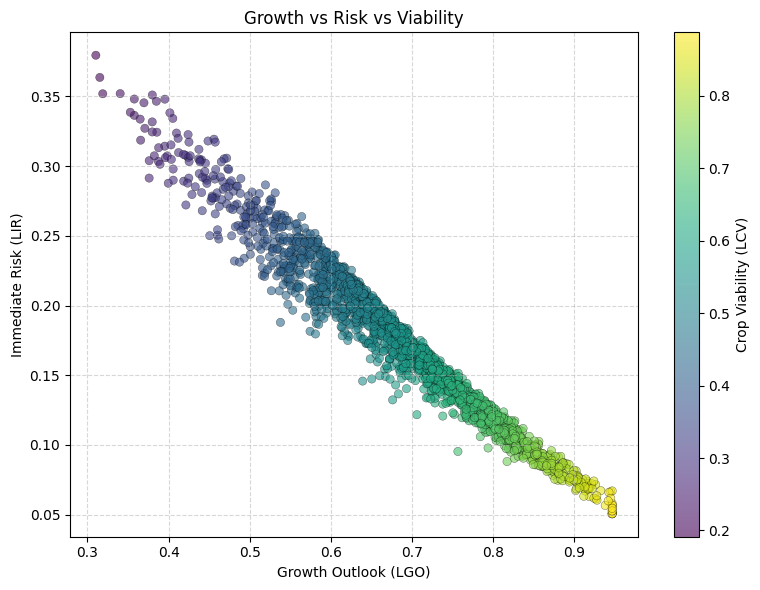

In [ ]:
plt.figure(figsize=(8, 6))

x = results_df["LGo (LongTerm_Growth_Outlook)"]
y = results_df["LIr (LongTerm_Immediate_Risk)"]
c = results_df["LCv (LongTerm_Crop_Viability)"]

sc = plt.scatter(
    x, y,
    c=c,
    cmap="viridis",
    alpha=0.6,
    edgecolors="black",
    linewidths=0.3
)

cbar = plt.colorbar(sc)
cbar.set_label("Crop Viability (LCV)")


plt.xlabel("Growth Outlook (LGO)")
plt.ylabel("Immediate Risk (LIR)")
plt.title("Growth vs Risk vs Viability")

# Grid
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

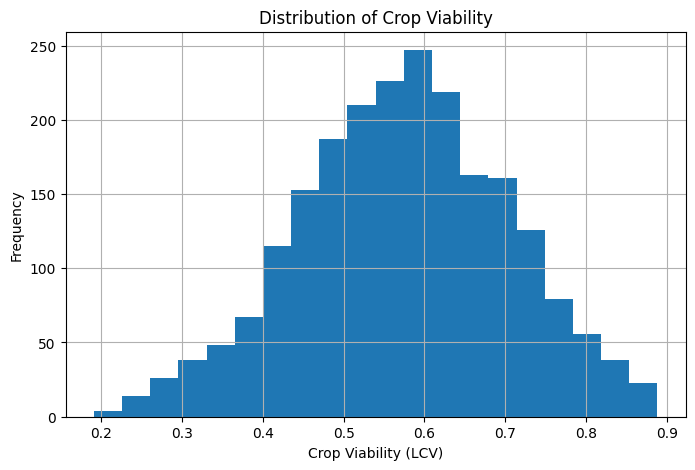

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(results_df["LCv (LongTerm_Crop_Viability)"], bins=20)

plt.title("Distribution of Crop Viability")
plt.xlabel("Crop Viability (LCV)")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

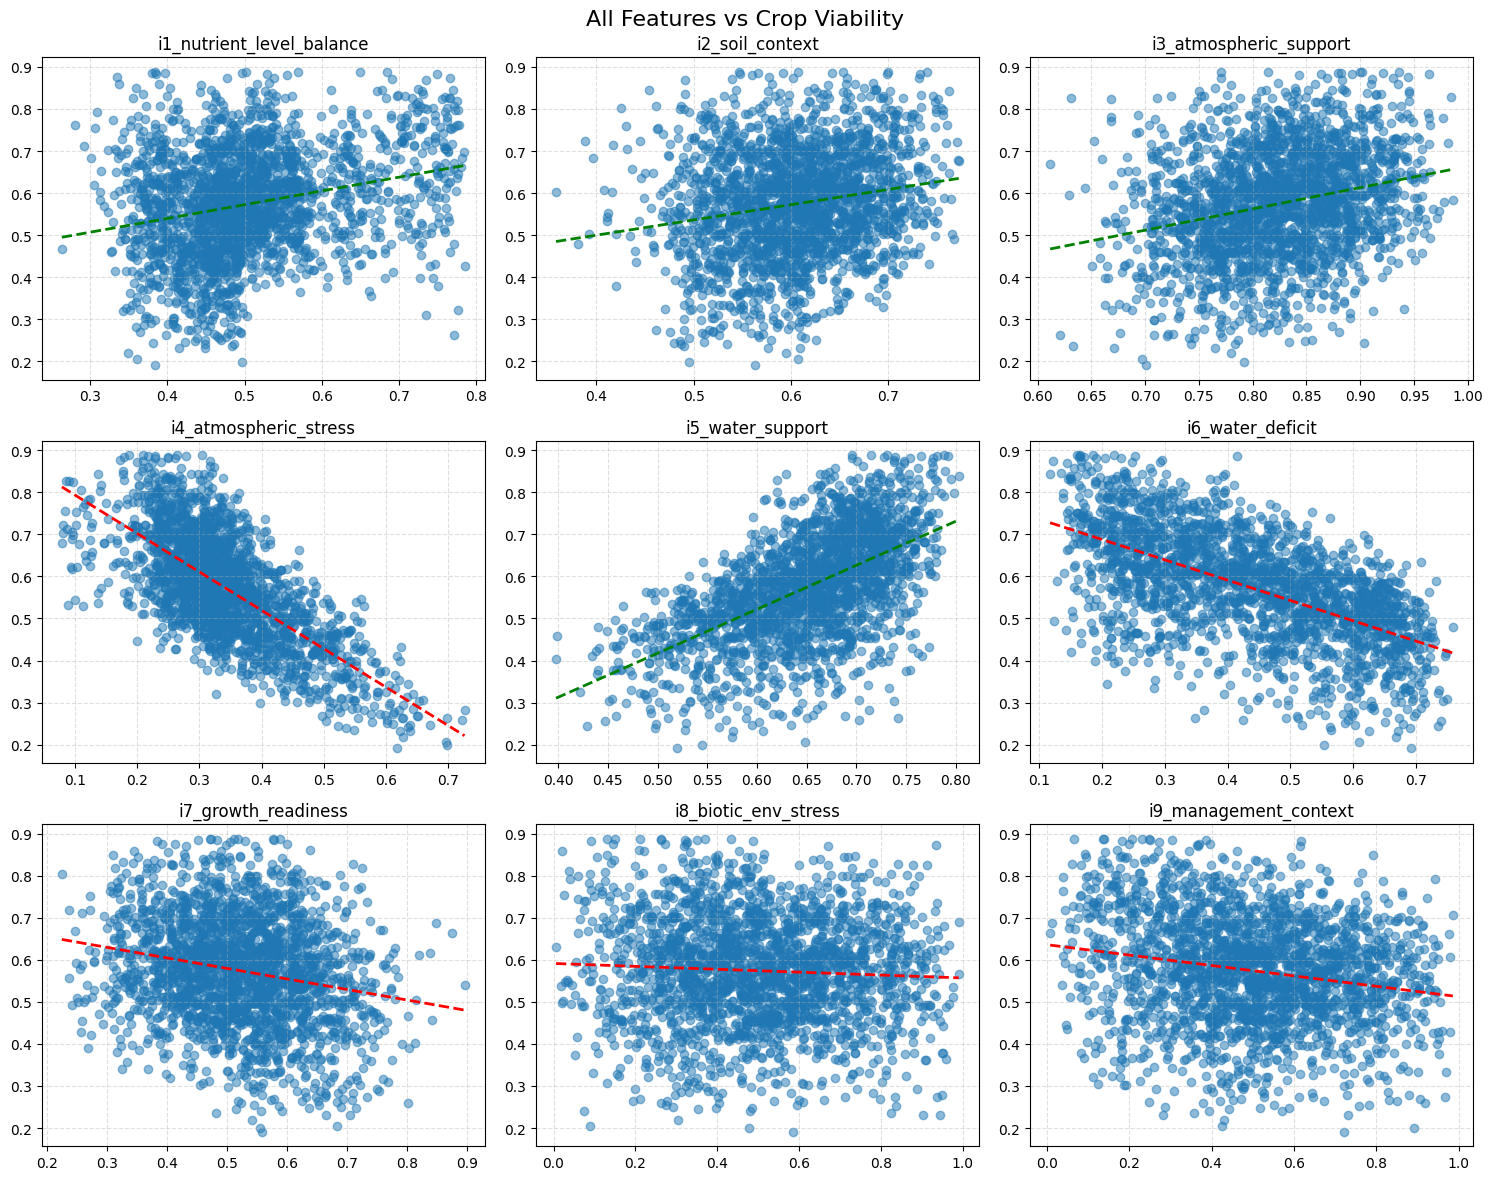

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

feature_cols = [
    "i1_nutrient_level_balance",
    "i2_soil_context",
    "i3_atmospheric_support",
    "i4_atmospheric_stress",
    "i5_water_support",
    "i6_water_deficit",
    "i7_growth_readiness",
    "i8_biotic_env_stress",
    "i9_management_context"
]

for ax, col in zip(axes.flatten(), feature_cols):
    x = df[col]
    y = results_df["LCv (LongTerm_Crop_Viability)"]

    ax.scatter(x, y, alpha=0.5)

    # fit line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)

    # decide color based on slope
    color = "green" if z[0] > 0 else "red"

    sorted_idx = np.argsort(x)
    ax.plot(
        x.iloc[sorted_idx],
        p(x.iloc[sorted_idx]),
        linestyle="--",
        linewidth=2,
        color=color
    )

    ax.set_title(col)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("All Features vs Crop Viability", fontsize=16)
plt.tight_layout()
plt.show()

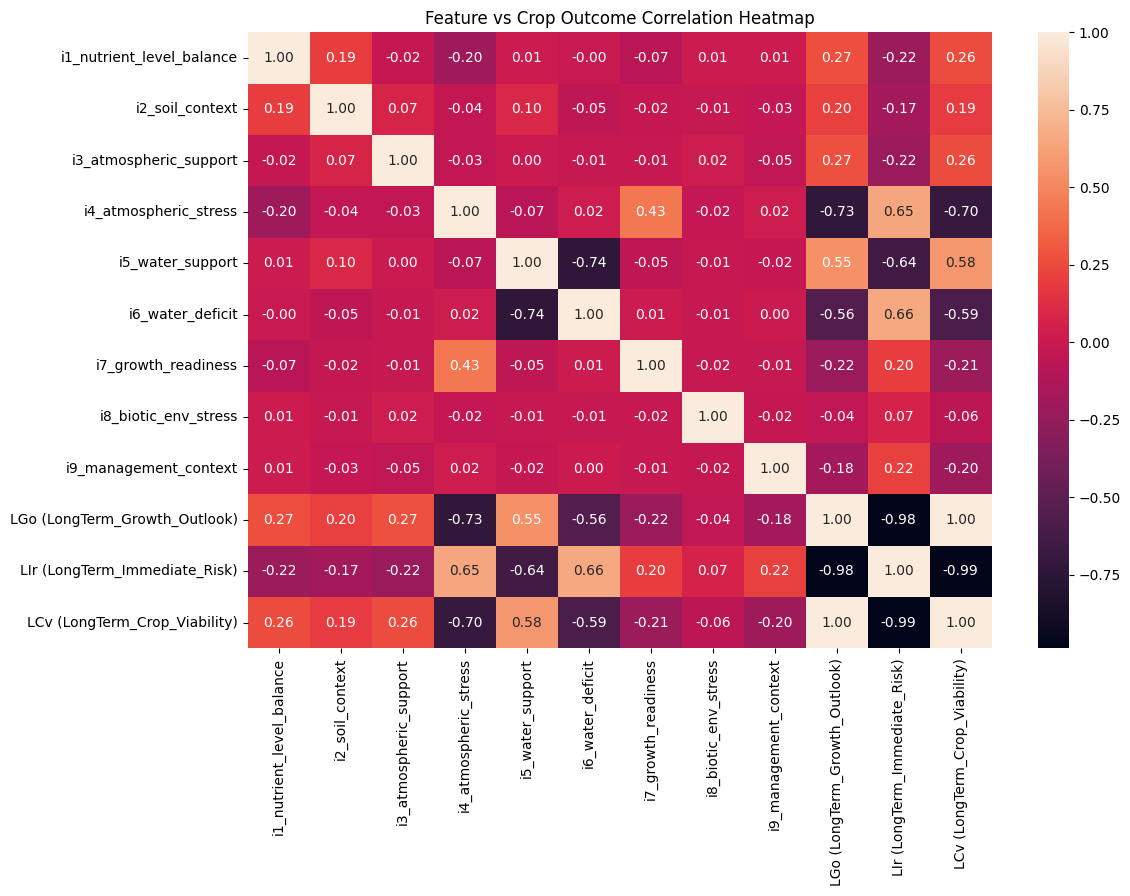

In [ ]:
import seaborn as sns

# combine inputs + outputs
heat_df = pd.concat([
    df[[
        "i1_nutrient_level_balance",
        "i2_soil_context",
        "i3_atmospheric_support",
        "i4_atmospheric_stress",
        "i5_water_support",
        "i6_water_deficit",
        "i7_growth_readiness",
        "i8_biotic_env_stress",
        "i9_management_context"
    ]],
    results_df[[
        "LGo (LongTerm_Growth_Outlook)",
        "LIr (LongTerm_Immediate_Risk)",
        "LCv (LongTerm_Crop_Viability)"
    ]]
], axis=1)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heat_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Feature vs Crop Outcome Correlation Heatmap")
plt.show()

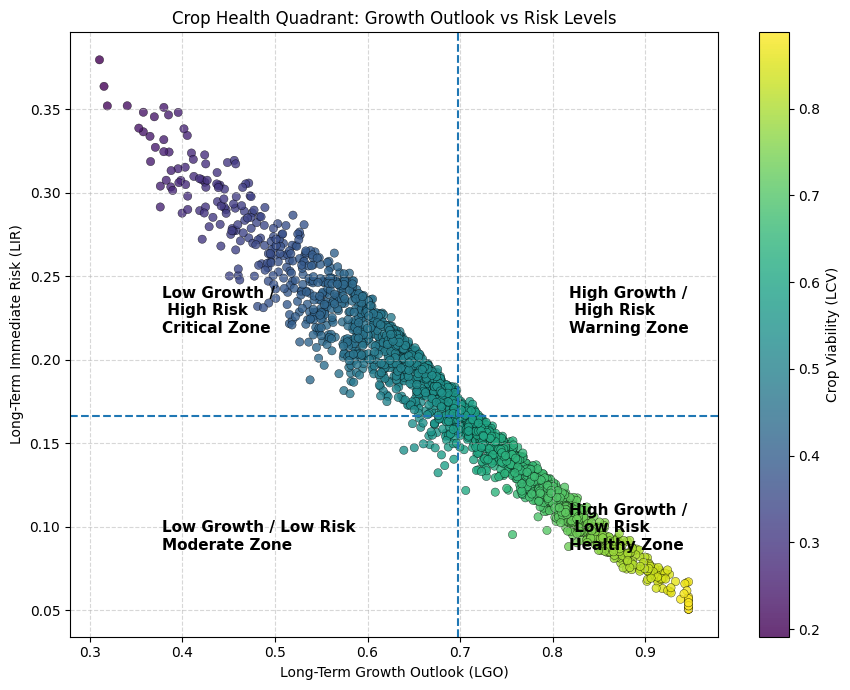

In [ ]:
plt.figure(figsize=(9, 7))

x = results_df["LGo (LongTerm_Growth_Outlook)"]
y = results_df["LIr (LongTerm_Immediate_Risk)"]
c = results_df["LCv (LongTerm_Crop_Viability)"]

x_cut = x.median()
y_cut = y.median()

sc = plt.scatter(
    x,
    y,
    c=c,
    cmap="viridis",
    alpha=0.8,
    edgecolors="black",
    linewidths=0.3
)

# decision lines
plt.axvline(x_cut, linestyle="--", linewidth=1.5)
plt.axhline(y_cut, linestyle="--", linewidth=1.5)

# === LABELS + ZONE MEANING ===
plt.text(
    x_cut + 0.12, y_cut - 0.08,
    "High Growth /\n Low Risk\nHealthy Zone",
    fontsize=11, weight="bold"
)

plt.text(
    x_cut + 0.12, y_cut + 0.05,
    "High Growth /\n High Risk\nWarning Zone",
    fontsize=11, weight="bold"
)

plt.text(
    x_cut - 0.32, y_cut - 0.08,
    "Low Growth / Low Risk\nModerate Zone",
    fontsize=11, weight="bold"
)

plt.text(
    x_cut - 0.32, y_cut + 0.05,
    "Low Growth /\n High Risk\nCritical Zone",
    fontsize=11, weight="bold"
)

# colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Crop Viability (LCV)")

plt.xlabel("Long-Term Growth Outlook (LGO)")
plt.ylabel("Long-Term Immediate Risk (LIR)")
plt.title("Crop Health Quadrant: Growth Outlook vs Risk Levels")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# FEATURE IMPORTANCE (CORRELATION-BASED)

features = [
    "i1_nutrient_level_balance",
    "i2_soil_context",
    "i3_atmospheric_support",
    "i4_atmospheric_stress",
    "i5_water_support",
    "i6_water_deficit",
    "i7_growth_readiness",
    "i8_biotic_env_stress",
    "i9_management_context"
]

targets = {
    "LCv (LongTerm_Crop_Viability)": "Crop Viability",
    "LGo (LongTerm_Growth_Outlook)": "Growth Outlook",
    "LIr (LongTerm_Immediate_Risk)": "Immediate Risk"
}

importance_results = []

for feature in features:
    for target_col, target_name in targets.items():
        corr = np.corrcoef(df[feature], results_df[target_col])[0, 1]

        importance_results.append({
            "feature": feature,
            "target": target_name,
            "correlation": corr,
            "importance": abs(corr)
        })

importance_df = pd.DataFrame(importance_results)

# sort by strongest effect
importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df.head(15)

,feature,target,correlation,importance
10,i4_atmospheric_stress,Growth Outlook,-0.729864,0.729864
9,i4_atmospheric_stress,Crop Viability,-0.696363,0.696363
17,i6_water_deficit,Immediate Risk,0.657784,0.657784
11,i4_atmospheric_stress,Immediate Risk,0.645997,0.645997
14,i5_water_support,Immediate Risk,-0.638510,0.638510
15,i6_water_deficit,Crop Viability,-0.593039,0.593039
12,i5_water_support,Crop Viability,0.577711,0.577711
16,i6_water_deficit,Growth Outlook,-0.555164,0.555164
13,i5_water_support,Growth Outlook,0.547576,0.547576
7,i3_atmospheric_support,Growth Outlook,0.272755,0.272755


In [ ]:
for name, group in importance_df.groupby("target"):
    print("\n", name, )
    print(group[["feature", "correlation", "importance"]])


 Crop Viability
                      feature  correlation  importance
9       i4_atmospheric_stress    -0.696363    0.696363
15           i6_water_deficit    -0.593039    0.593039
12           i5_water_support     0.577711    0.577711
6      i3_atmospheric_support     0.256036    0.256036
0   i1_nutrient_level_balance     0.255081    0.255081
18        i7_growth_readiness    -0.211356    0.211356
24      i9_management_context    -0.199505    0.199505
3             i2_soil_context     0.190751    0.190751
21       i8_biotic_env_stress    -0.055812    0.055812

 Growth Outlook
                      feature  correlation  importance
10      i4_atmospheric_stress    -0.729864    0.729864
16           i6_water_deficit    -0.555164    0.555164
13           i5_water_support     0.547576    0.547576
7      i3_atmospheric_support     0.272755    0.272755
1   i1_nutrient_level_balance     0.267380    0.267380
19        i7_growth_readiness    -0.221407    0.221407
4             i2_soil_context  

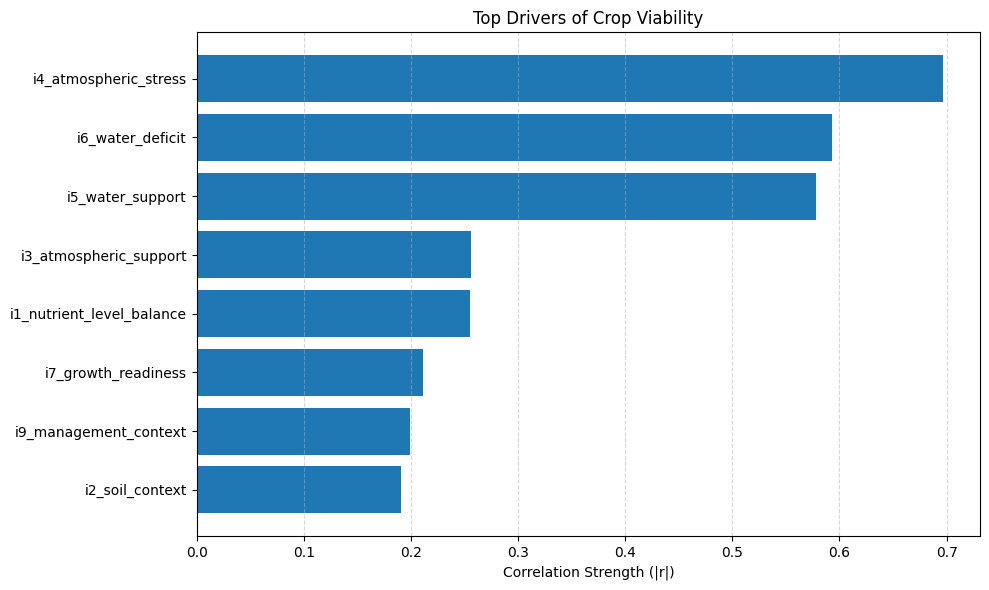

In [ ]:
# BAR PLOT: TOP FEATURES

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# filter for Crop Viability (main metric)
df_plot = importance_df[importance_df["target"] == "Crop Viability"].head(8)

plt.barh(
    df_plot["feature"],
    df_plot["importance"]
)

plt.xlabel("Correlation Strength (|r|)")
plt.title("Top Drivers of Crop Viability")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

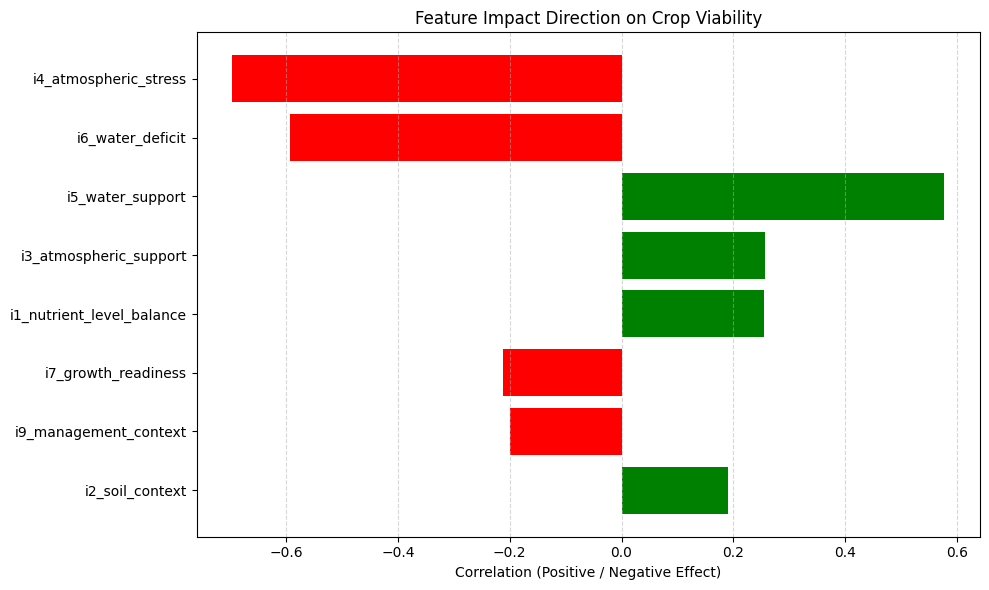

In [ ]:
plt.figure(figsize=(10, 6))

df_plot = importance_df[importance_df["target"] == "Crop Viability"].head(8)

colors = ["green" if c > 0 else "red" for c in df_plot["correlation"]]

plt.barh(
    df_plot["feature"],
    df_plot["correlation"],
    color=colors
)

plt.xlabel("Correlation (Positive / Negative Effect)")
plt.title("Feature Impact Direction on Crop Viability")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

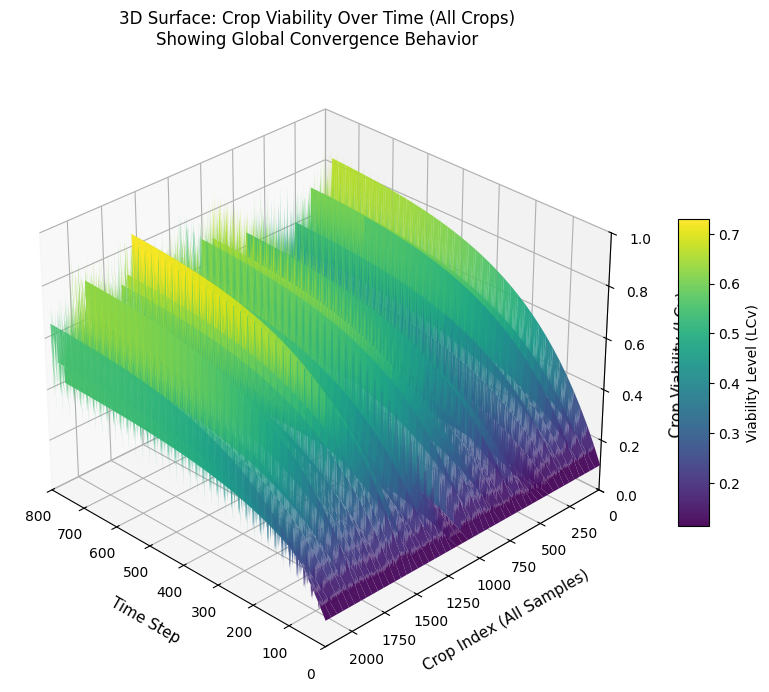

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# USE ALL DATA
sample_df = df  # all crops

Z = []

for _, row in sample_df.iterrows():
    sim = run_crop_model(
        row,
        T=T,
        dt=dt,
        eta_go=eta_go,
        eta_ir=eta_ir,
        eta_cv=eta_cv
    )
    Z.append(sim["LCv (LongTerm_Crop_Viability)"])

Z = np.array(Z)

#  DOWNSAMPLE TIME (IMPORTANT)
step = 20   # adjust

Z = Z[:, ::step]
time = np.arange(T)[::step]

crop_idx = np.arange(len(sample_df))
T_grid, C_grid = np.meshgrid(time, crop_idx)

# PLOT
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    T_grid,
    C_grid,
    Z,
    cmap="viridis",
    edgecolor='none',
    alpha=0.95
)

# LABELS
ax.set_xlabel("Time Step", fontsize=11, labelpad=10)
ax.set_ylabel("Crop Index (All Samples)", fontsize=11, labelpad=10)
ax.set_zlabel("Crop Viability (LCv)", fontsize=11, labelpad=10)

ax.set_xlim(0, T)
ax.set_ylim(0, len(sample_df))
ax.set_zlim(0, 1)

ax.set_title(
    "3D Surface: Crop Viability Over Time (All Crops)\n"
    "Showing Global Convergence Behavior",
    fontsize=12,
    pad=15
)

cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
cbar.set_label("Viability Level (LCv)")

ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.show()

In [ ]:
# assuming you stored results for all rows
final_lcv_values = []

for idx, row in df.iterrows():
    results = run_crop_model(row)
    final_lcv_values.append(results["LCv (LongTerm_Crop_Viability)"][-1])

final_lcv_values = np.array(final_lcv_values)

print("Mean LCv:", np.mean(final_lcv_values))
print("Min LCv:", np.min(final_lcv_values))
print("Max LCv:", np.max(final_lcv_values))

Mean LCv: 0.5739560600541662
Min LCv: 0.19140415854477755
Max LCv: 0.8878753137778461


In [ ]:
healthy = np.sum(final_lcv_values >= 0.75)
moderate = np.sum((final_lcv_values >= 0.55) & (final_lcv_values < 0.75))
warning = np.sum((final_lcv_values >= 0.35) & (final_lcv_values < 0.55))
critical = np.sum(final_lcv_values < 0.35)

total = len(final_lcv_values)

print("Healthy:", healthy/total)
print("Moderate:", moderate/total)
print("Warning:", warning/total)
print("Critical:", critical/total)

Healthy: 0.0890909090909091
Moderate: 0.48363636363636364
Critical: 0.04772727272727273


In [ ]:
# To see the total unique list of crops
print("Total Crop Types:", df['label'].nunique())
print(df['label'].unique())

# To see how many rows you have for each crop
print(df['label'].value_counts())

Total Crop Types: 22
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64
